## UTS

## SOAL 1

In [1]:
!pip install Sastrawi
!pip install gensim

In [2]:
import pandas as pd
import numpy as np
import re
import string
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora, models
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_excel('Berita.xlsx')
pd.set_option('display.max_rows', None)
print("Jumlah total berita:", len(df))

display(df)

Jumlah total berita: 1500


,No,judul,berita,tanggal,kategori,link
0,1,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,"Minggu, 01 Des 2024 23:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
1,2,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...","Minggu, 01 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412012...
2,3,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,"Minggu, 01 Des 2024 19:40 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
3,4,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,"Minggu, 01 Des 2024 19:03 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
4,5,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,"Minggu, 01 Des 2024 19:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
5,6,AHY Buka-bukaan Nasib Kelanjutan Pembangunan I...,Menko Bidang Infrastruktur dan Pembangunan Kew...,"Minggu, 01 Des 2024 18:20 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412011...
6,7,Badan Gizi Soal Biaya Makan Gratis Rp10 Ribu: ...,Kepala Badan Gizi Nasional Dadan Hindayana men...,"Senin, 02 Des 2024 21:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412022...
7,8,Zulhas Minta Tambahan Anggaran Rp510 M Demi Ca...,Menteri Koordinator Bidang Pangan Zulkifli Has...,"Senin, 02 Des 2024 20:45 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412021...
8,9,PLN Akan Uji Coba PLTS IKN 22 Desember,Uji coba alias commissioning pembangkit listri...,"Senin, 02 Des 2024 20:20 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412021...
9,10,"Profil Jhony Saputra, Anak Haji Isam yang Jadi...",Anak crazy rich pengusaha sawit Kalimantan Sam...,"Senin, 02 Des 2024 20:00 WIB",Ekonomi,https://www.cnnindonesia.com/ekonomi/202412021...


In [5]:
import pandas as pd
import re

# --- 1. Baca dataset ---
df = pd.read_excel("Berita.xlsx")
print("Jumlah total data:", len(df))

# --- 2. Bersihkan data kosong atau duplikat ---
df = df.drop_duplicates(subset=["berita"])
df = df.dropna(subset=["berita"])
df = df.reset_index(drop=True)

# --- 3. Fungsi pembersihan teks cepat ---
def clean_text_fast(text):
    text = str(text).lower()                    # lowercase
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)   # hapus angka dan tanda baca
    text = re.sub(r'\s+', ' ', text).strip()   # hapus spasi berlebih
    return text

# --- 4. Terapkan pembersihan ---
df['clean_text'] = df['berita'].apply(clean_text_fast)

# --- 5. Tampilkan hasil ---
print("=== Contoh hasil preprocessing cepat ===")
display(df[['judul', 'berita', 'clean_text']].head(10))

Jumlah total data: 1500
=== Contoh hasil preprocessing cepat ===


,judul,berita,clean_text
0,Airlangga Harap Kenaikan UMP Tingkatkan Daya B...,Menteri Koordinator (Menko) Bidang Perekonomia...,menteri koordinator menko bidang perekonomian ...
1,PT SIER Beri Penghargaan untuk 50 Tenant Terba...,"Dalam rangka memeriahkan hari jadi ke-50, PT S...",dalam rangka memeriahkan hari jadi ke pt surab...
2,Prabowo Bakal Bentuk Kementerian Penerimaan Ne...,Wacana Presiden Prabowo Subianto akan membentu...,wacana presiden prabowo subianto akan membentu...
3,Sinergi Kemenag & BPJS Ketenagakerjaan Lindung...,BPJS Ketenagakerjaan dan Kementerian Agama (Ke...,bpjs ketenagakerjaan dan kementerian agama kem...
4,Pemerintah Segera Bentuk Satgas PHK Usai Tetap...,Pemerintah akan segera membentuk Satuan Tugas ...,pemerintah akan segera membentuk satuan tugas ...
5,AHY Buka-bukaan Nasib Kelanjutan Pembangunan I...,Menko Bidang Infrastruktur dan Pembangunan Kew...,menko bidang infrastruktur dan pembangunan kew...
6,Badan Gizi Soal Biaya Makan Gratis Rp10 Ribu: ...,Kepala Badan Gizi Nasional Dadan Hindayana men...,kepala badan gizi nasional dadan hindayana men...
7,Zulhas Minta Tambahan Anggaran Rp510 M Demi Ca...,Menteri Koordinator Bidang Pangan Zulkifli Has...,menteri koordinator bidang pangan zulkifli has...
8,PLN Akan Uji Coba PLTS IKN 22 Desember,Uji coba alias commissioning pembangkit listri...,uji coba alias commissioning pembangkit listri...
9,"Profil Jhony Saputra, Anak Haji Isam yang Jadi...",Anak crazy rich pengusaha sawit Kalimantan Sam...,anak crazy rich pengusaha sawit kalimantan sam...


In [16]:
import gensim
from gensim import corpora
import numpy as np
import pandas as pd

# --- Tokenisasi dari teks bersih ---
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

# --- Membuat dictionary dan corpus untuk LDA ---
dictionary = corpora.Dictionary(df['tokens'])
corpus = [dictionary.doc2bow(text) for text in df['tokens']]

# --- Membuat model LDA ---
num_topics = 50
lda_model = gensim.models.LdaModel(
    corpus,
    num_topics=num_topics,
    id2word=dictionary,
    passes=10,
    random_state=42
)

# --- Tampilkan daftar topik ---
topics = lda_model.print_topics(num_words=20)
topics_df = pd.DataFrame(topics, columns=['Topik_ID', 'Kata_Kunci'])
print("=== Daftar Topik dari LDA ===")
display(topics_df)

# --- Konversi hasil LDA menjadi fitur numerik ---
def get_lda_features(corpus, model, num_topics):
    features = []
    for doc in corpus:
        topic_dist = [0] * num_topics
        for topic_id, prob in model.get_document_topics(doc):
            topic_dist[topic_id] = prob
        features.append(topic_dist)
    return np.array(features)

X_topics = get_lda_features(corpus, lda_model, num_topics)

# --- Simpan hasil fitur ke DataFrame ---
lda_features_df = pd.DataFrame(X_topics, columns=[f'Topic_{i+1}' for i in range(num_topics)])
df_lda = pd.concat([df[['clean_text']], lda_features_df], axis=1)

print("=== Contoh Fitur LDA (10 Dokumen Pertama) ===")
display(df_lda.head(10))

=== Daftar Topik dari LDA ===


,Topik_ID,Kata_Kunci
0,2,"0.038*""di"" + 0.029*""banjir"" + 0.023*""dan"" + 0...."
1,19,"0.031*""yang"" + 0.020*""di"" + 0.018*""dan"" + 0.01..."
2,7,"0.033*""di"" + 0.027*""israel"" + 0.024*""dan"" + 0...."
3,12,"0.017*""yang"" + 0.015*""di"" + 0.013*""dan"" + 0.00..."
4,48,"0.034*""menit"" + 0.033*""ke"" + 0.024*""gawang"" + ..."
5,42,"0.031*""gunung"" + 0.028*""di"" + 0.024*""erupsi"" +..."
6,46,"0.018*""di"" + 0.018*""kamboja"" + 0.016*""indonesi..."
7,11,"0.019*""di"" + 0.017*""yang"" + 0.012*""dan"" + 0.01..."
8,28,"0.014*""persik"" + 0.014*""air"" + 0.011*""wika"" + ..."
9,26,"0.035*""laut"" + 0.027*""pagar"" + 0.026*""di"" + 0...."


=== Contoh Fitur LDA (10 Dokumen Pertama) ===


,clean_text,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,...,Topic_41,Topic_42,Topic_43,Topic_44,Topic_45,Topic_46,Topic_47,Topic_48,Topic_49,Topic_50
0,menteri koordinator menko bidang perekonomian ...,0.000000,0.347055,0.0,0.0,0.000000,0.148438,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,dalam rangka memeriahkan hari jadi ke pt surab...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,wacana presiden prabowo subianto akan membentu...,0.000000,0.365845,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.406495,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,bpjs ketenagakerjaan dan kementerian agama kem...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,pemerintah akan segera membentuk satuan tugas ...,0.000000,0.050997,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,menko bidang infrastruktur dan pembangunan kew...,0.000000,0.000000,0.0,0.0,0.000000,0.339904,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,kepala badan gizi nasional dadan hindayana men...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.096489,0.078862,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,menteri koordinator bidang pangan zulkifli has...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,uji coba alias commissioning pembangkit listri...,0.016076,0.000000,0.0,0.0,0.013828,0.718770,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,anak crazy rich pengusaha sawit kalimantan sam...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.000000,0.996524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
from sklearn.model_selection import train_test_split

# --- Fitur LDA ---
X = lda_features_df.values  # hanya fitur LDA
y = df['kategori'].values      # target label

# --- Membagi data latih dan data uji (80% latih, 20% uji) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran Data Latih:", X_train.shape)
print("Ukuran Data Uji:", X_test.shape)

Ukuran Data Latih: (1200, 50)
Ukuran Data Uji: (300, 50)


In [20]:
from sklearn.model_selection import train_test_split

# --- Kolom target (label) ---
y = df['kategori']  # ubah sesuai nama kolom label kamu

# --- Split data (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(
    lda_features_df, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

print("=== Naïve Bayes ===")
print("Akurasi:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

=== Naïve Bayes ===
Akurasi: 0.8433333333333334
               precision    recall  f1-score   support

      Ekonomi       0.80      0.88      0.84        75
Internasional       0.83      0.83      0.83        75
     Nasional       0.77      0.72      0.74        75
     Olahraga       0.97      0.95      0.96        75

     accuracy                           0.84       300
    macro avg       0.84      0.84      0.84       300
 weighted avg       0.84      0.84      0.84       300



In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# --- Misal kolom label bernama 'label' ---
X = df['clean_text']
y = df['kategori']  # ganti sesuai kolom targetmu

# --- Split data ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Ubah teks menjadi vektor numerik ---
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# --- Train SVM ---
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_vec, y_train)
y_pred_svm = svm.predict(X_test_vec)

# --- Evaluasi ---
print("=== SVM ===")
print("Akurasi:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

=== SVM ===
Akurasi: 0.95
               precision    recall  f1-score   support

      Ekonomi       0.94      0.92      0.93        73
Internasional       0.94      0.96      0.95        84
     Nasional       0.92      0.93      0.92        70
     Olahraga       1.00      0.99      0.99        73

     accuracy                           0.95       300
    macro avg       0.95      0.95      0.95       300
 weighted avg       0.95      0.95      0.95       300



## SOAL 2

Membaca Dataset

In [16]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')
print("Jumlah total data:", len(df))
display(df.head())

text_column = 'Text' if 'Text' in df.columns else df.columns[0]

Jumlah total data: 5572


,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,2,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,4,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,5,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Inisialisasi stopwords

In [30]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())

Pembersihan Teks

In [17]:
def clean_text(text):
    text = str(text).lower()                      # huruf kecil semua
    text = re.sub(r'[^a-z\s]', ' ', text)         # hapus tanda baca & angka
    text = ' '.join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])
    return text

Membersihkan semua Teks

In [20]:
df['cleaned_text'] = df[text_column].apply(clean_text)

Representasi teks dengan TF-IDF

In [21]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['cleaned_text'])

Clustering dengan K-Means

In [22]:
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

Visualisasi cluster

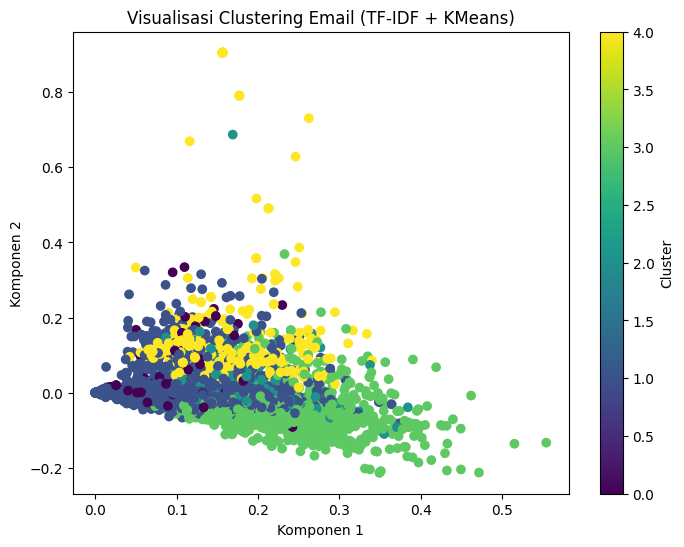

In [24]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
reduced_data = svd.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(reduced_data[:,0], reduced_data[:,1], c=df['cluster'], cmap='viridis')
plt.title("Visualisasi Clustering Email (TF-IDF + KMeans)")
plt.xlabel("Komponen 1")
plt.ylabel("Komponen 2")
plt.colorbar(label='Cluster')
plt.show()

Menampilkan Kata Dominan per Cluster

In [31]:
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

clusters_top_words = []  # untuk menyimpan hasil

for i in range(n_clusters):
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    clusters_top_words.append({
        "Cluster": i,
        "Top Words": ', '.join(top_words)
    })

df_top_words = pd.DataFrame(clusters_top_words)
display(df_top_words)

,Cluster,Top Words
0,0,"then, lor, go, come, wat, but, wan, me, dun, not"
1,1,"to, the, is, in, it, my, and, me, of, that"
2,2,"lt, gt, you, the, to, in, decimal, is, for, min"
3,3,"you, are, to, and, the, me, do, how, in, that"
4,4,"call, later, you, sorry, your, to, ll, free, p..."


Menampilkan Contoh Email Tiap Cluster

In [27]:
for i in range(n_clusters):
    print(f"\n=== Contoh Email Cluster {i} ===")
    display(df[df['cluster']==i][[text_column]].head(3))


=== Contoh Email Cluster 0 ===


,Text
3,U dun say so early hor... U c already then say...
22,So Ì_ pay first lar... Then when is da stock c...
23,Aft i finish my lunch then i go str down lor. ...



=== Contoh Email Cluster 1 ===


,Text
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...



=== Contoh Email Cluster 2 ===


,Text
44,Great! I hope you like your man well endowed. ...
51,"A gram usually runs like &lt;#&gt; , a half e..."
55,Do you know what Mallika Sherawat did yesterda...



=== Contoh Email Cluster 3 ===


,Text
13,I've been searching for the right words to tha...
20,Is that seriously how you spell his name?
24,Ffffffffff. Alright no way I can meet up with ...



=== Contoh Email Cluster 4 ===


,Text
8,WINNER!! As a valued network customer you have...
9,Had your mobile 11 months or more? U R entitle...
42,07732584351 - Rodger Burns - MSG = We tried to...
